<a href="https://www.kaggle.com/code/saibhossain/baseline-graph-rag?scriptVersionId=311602180" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

GraphRAG (Graph Retrieval-Augmented Generation) is an advanced AI framework that combines knowledge graphs with Large Language Models (LLMs) to improve accuracy, context, and reasoning

# Architecture

    PDFs
     ↓
    Load + Chunk
     ↓
    Entity / Relation Extraction
     ↓
    Knowledge Graph
     ↓
    Query
     ↓
    Graph Search
     ↓
    Relevant papers / entities
     ↓
    Chunk Retrieval from connected docs
     ↓
    LLM Answer

###  We will build: 
    Load PDFs
    Chunk documents
    Create document metadata
    Extract graph nodes
    paper
    dataset
    method
    metric
    task
    Extract graph edges
    paper uses dataset
    paper uses method
    paper mentions metric
    paper addresses task
    Store graph
    Search graph from query
    Use graph-filtered chunks
    Answer with graph-aware context

# Baseline_Graph_RAG

In [4]:
!pip -q install langchain langchain-community langchain-core
!pip -q install langchain-huggingface langchain-google-genai langchain-groq
!pip install -q langchain-classic #
!pip -q install sentence-transformers faiss-cpu pypdf rank-bm25 networkx matplotlib

In [5]:
import os
import re
import glob
import json
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple, Set
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers.ensemble import EnsembleRetriever

In [24]:
@dataclass
class GraphRAGConfig:
    pdf_dir: str = "/kaggle/input/datasets/saibhossain/rag-practice"
    embedding_model_name: str = "sentence-transformers/all-MiniLM-L6-v2"
    llm_model_name: str = "gemini-2.5-flash"
    temperature: float = 0.2
    
    chunk_size: int = 800
    chunk_overlap: int = 150

    dense_top_k: int = 5
    sparse_top_k: int = 5
    final_top_k: int = 5

config = GraphRAGConfig()
print(config)

GraphRAGConfig(pdf_dir='/kaggle/input/datasets/saibhossain/rag-practice', embedding_model_name='sentence-transformers/all-MiniLM-L6-v2', llm_model_name='gemini-2.5-flash', temperature=0.2, chunk_size=800, chunk_overlap=150, dense_top_k=5, sparse_top_k=5, final_top_k=5)


## Load PDFs

In [7]:
def normalize_text(x: str) -> str:
    x = x.lower().strip()
    x = re.sub(r"\s+", " ", x)
    return x


def normalize_filename(name: str) -> str:
    base = os.path.basename(name)
    base = base.replace(".pdf", "")
    base = re.sub(r"[_\-]+", " ", base)
    base = re.sub(r"\s+", " ", base).strip()
    return base.lower()


def get_pdf_paths(pdf_dir: str) -> List[str]:
    return sorted(glob.glob(os.path.join(pdf_dir, "*.pdf")))


def load_pdfs_from_folder(pdf_dir: str) -> List[Document]:
    pdf_paths = get_pdf_paths(pdf_dir)

    if not pdf_paths:
        raise FileNotFoundError(f"No PDF files found in: {pdf_dir}")

    print("=" * 100)
    print("STEP 1: LOADING PDF FILES")
    print("=" * 100)
    print(f"Found {len(pdf_paths)} PDF files\n")

    all_docs = []

    for pdf_path in pdf_paths:
        file_name = os.path.basename(pdf_path)
        file_stem = file_name.replace(".pdf", "")

        print(f"Loading: {file_name}")
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()

        for doc in docs:
            doc.metadata["file_name"] = file_name
            doc.metadata["file_stem"] = file_stem
            doc.metadata["normalized_file_name"] = normalize_filename(file_name)
            doc.metadata["source_path"] = pdf_path

        print(f"  -> Pages loaded: {len(docs)}")
        if docs:
            preview = docs[0].page_content[:200].replace("\n", " ")
            print(f"  -> Preview: {preview}")
        print("-" * 100)

        all_docs.extend(docs)

    print(f"\nTotal pages loaded: {len(all_docs)}")
    return all_docs


documents = load_pdfs_from_folder(config.pdf_dir)

STEP 1: LOADING PDF FILES
Found 12 PDF files

Loading: 1-s2.0-S1877050925029461-main.pdf
  -> Pages loaded: 10
  -> Preview: ScienceDirect Available online at www.sciencedirect.com Procedia Computer Science 270 (2025) 1517–1526 1877-0509 © 2025 The Authors. Published by Elsevier B.V . This is an open access article under th
----------------------------------------------------------------------------------------------------
Loading: 2404.03936v2.pdf
  -> Pages loaded: 38
  -> Preview: 1  GRSM-2023-00112    Deep Learning for Satellite Image Time Series  Analysis: A Review    Lynn Miller, Member, IEEE, Charlotte Pelletier, and Geoffrey I. Webb, Fellow, IEEE    Earth observation  (EO)
----------------------------------------------------------------------------------------------------
Loading: 2510.26923v1.pdf
  -> Pages loaded: 5
  -> Preview: SCALE-A W ARE CURRICULUM LEARNING FOR DA TA-EFFICIENT LUNG NODULE DETECTION WITH YOLOV11 Yi Luo1 Yike Guo1 Hamed Hooshangnejad2 Kai Ding2 1Departmen

In [8]:
def chunk_documents(documents: List[Document], chunk_size: int, chunk_overlap: int) -> List[Document]:
    print("=" * 100)
    print("STEP 2: CHUNKING DOCUMENTS")
    print("=" * 100)

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )

    chunks = splitter.split_documents(documents)

    file_chunk_counter = defaultdict(int)

    for i, chunk in enumerate(chunks):
        file_name = chunk.metadata.get("file_name", "unknown_file")
        chunk.metadata["global_chunk_id"] = i
        chunk.metadata["chunk_id"] = file_chunk_counter[file_name]
        chunk.metadata["chunk_len"] = len(chunk.page_content)
        file_chunk_counter[file_name] += 1

    print(f"Total chunks: {len(chunks)}")
    print("Example chunk metadata:")
    print(chunks[0].metadata)
    print("\nExample chunk text:")
    print(chunks[0].page_content[:800])

    return chunks


chunks = chunk_documents(documents, config.chunk_size, config.chunk_overlap)

STEP 2: CHUNKING DOCUMENTS
Total chunks: 1512
Example chunk metadata:
{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.0 (Windows)', 'creationdate': '2025-11-05T01:14:12+05:30', 'authoritativedomain[1]': 'sciencedirect.com', 'authoritativedomain[2]': 'elsevier.com', 'crossmarkdomains[1]': 'sciencedirect.com', 'crossmarkdomains[2]': 'elsevier.com', 'crossmarkdomainexclusive': '2010-04-23', 'crossmarkmajorversiondate': '2010-04-23', 'elsevierwebpdfspecifications': '7.0', 'moddate': '2025-11-05T16:17:44+05:30', 'trapped': '/False', 'doi': '10.1016/j.procs.2025.09.273', 'robots': 'noindex', 'source': '/kaggle/input/datasets/saibhossain/rag-practice/1-s2.0-S1877050925029461-main.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1517', 'file_name': '1-s2.0-S1877050925029461-main.pdf', 'file_stem': '1-s2.0-S1877050925029461-main', 'normalized_file_name': '1 s2.0 s1877050925029461 main', 'source_path': '/kaggle/input/datasets/saibhossain/rag-practice/1-s2.0-S18770509250294

In [9]:
def clean_preview_text(text: str, max_chars: int = 1500) -> str:
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]


def build_document_catalog(documents: List[Document]) -> List[Dict[str, Any]]:
    print("=" * 100)
    print("STEP 3: BUILDING DOCUMENT CATALOG")
    print("=" * 100)

    grouped = defaultdict(list)
    for doc in documents:
        grouped[doc.metadata["file_name"]].append(doc)

    catalog = []

    for file_name, docs in grouped.items():
        docs = sorted(docs, key=lambda d: d.metadata.get("page", 0))
        first_page_text = docs[0].page_content if docs else ""
        preview_text = clean_preview_text(first_page_text)

        catalog.append({
            "file_name": file_name,
            "normalized_file_name": normalize_filename(file_name),
            "page_count": len(docs),
            "preview_text": preview_text
        })

    catalog = sorted(catalog, key=lambda x: x["file_name"])

    print(f"Catalog size: {len(catalog)}")
    for item in catalog[:5]:
        print(item["file_name"], "| pages =", item["page_count"])

    return catalog


document_catalog = build_document_catalog(documents)

STEP 3: BUILDING DOCUMENT CATALOG
Catalog size: 12
1-s2.0-S1877050925029461-main.pdf | pages = 10
2404.03936v2.pdf | pages = 38
2510.26923v1.pdf | pages = 5
2602.10481v1.pdf | pages = 16
AI-Powered Lung Cancer Detection- Assessing VGG16 and CNN Architectures for CT Scan Image Classification.pdf | pages = 30


## Build simple extractor dictionaries

For baseline Graph RAG, we’ll use keyword dictionaries.

In [10]:
DATASET_PATTERNS = [
    "lidc-idri", "lung-pet-ct-dx", "lotus dataset", "kaggle chest ct-scan images",
    "chest ct-scan images dataset", "ncbi", "tcga", "sentinel-2", "modis"
]

METHOD_PATTERNS = [
    "cnn", "vgg16", "vgg19", "resnet50", "resnet", "densenet201", "convnext",
    "inceptionv3", "yolov8", "yolo", "capsnet", "multiresunet", "deeply supervised multiresunet",
    "wavelet transform", "dwt", "cdl", "collaborative deep learning",
    "rnn", "ann", "svm", "random forest", "knn"
]

METRIC_PATTERNS = [
    "accuracy", "precision", "recall", "f1-score", "f1 score", "auc", "auroc",
    "rmse", "r2", "dice coefficient", "kappa score", "mcc", "roc curve"
]

TASK_PATTERNS = [
    "lung cancer detection", "lung nodule detection", "classification",
    "segmentation", "survival prediction", "prediction", "diagnosis"
]

## Entity extraction function

In [11]:
def find_pattern_matches(text: str, patterns: List[str]) -> List[str]:
    text_norm = normalize_text(text)
    found = []

    for p in patterns:
        if p in text_norm:
            found.append(p)

    return sorted(list(set(found)))


def extract_entities_from_document(doc_info: Dict[str, Any]) -> Dict[str, List[str]]:
    text = f"{doc_info['file_name']} {doc_info['preview_text']}"
    return {
        "datasets": find_pattern_matches(text, DATASET_PATTERNS),
        "methods": find_pattern_matches(text, METHOD_PATTERNS),
        "metrics": find_pattern_matches(text, METRIC_PATTERNS),
        "tasks": find_pattern_matches(text, TASK_PATTERNS)
    }

## Build the graph

In [12]:
def build_knowledge_graph(document_catalog: List[Dict[str, Any]]) -> nx.MultiDiGraph:
    print("=" * 100)
    print("STEP 4: BUILDING KNOWLEDGE GRAPH")
    print("=" * 100)

    G = nx.MultiDiGraph()

    for doc in document_catalog:
        paper_node = f"paper::{doc['file_name']}"
        G.add_node(
            paper_node,
            node_type="paper",
            label=doc["file_name"]
        )

        extracted = extract_entities_from_document(doc)

        for ds in extracted["datasets"]:
            ds_node = f"dataset::{ds}"
            G.add_node(ds_node, node_type="dataset", label=ds)
            G.add_edge(paper_node, ds_node, relation="uses_dataset")

        for method in extracted["methods"]:
            method_node = f"method::{method}"
            G.add_node(method_node, node_type="method", label=method)
            G.add_edge(paper_node, method_node, relation="uses_method")

        for metric in extracted["metrics"]:
            metric_node = f"metric::{metric}"
            G.add_node(metric_node, node_type="metric", label=metric)
            G.add_edge(paper_node, metric_node, relation="reports_metric")

        for task in extracted["tasks"]:
            task_node = f"task::{task}"
            G.add_node(task_node, node_type="task", label=task)
            G.add_edge(paper_node, task_node, relation="addresses_task")

    print(f"Total nodes: {G.number_of_nodes()}")
    print(f"Total edges: {G.number_of_edges()}")

    return G


knowledge_graph = build_knowledge_graph(document_catalog)

STEP 4: BUILDING KNOWLEDGE GRAPH
Total nodes: 36
Total edges: 42


In [13]:
# inspect Graph
def inspect_graph(G: nx.MultiDiGraph, max_nodes: int = 20):
    print("=" * 100)
    print("STEP 5: GRAPH INSPECTION")
    print("=" * 100)

    print("Sample nodes:")
    for i, (node, attrs) in enumerate(G.nodes(data=True)):
        print(node, attrs)
        if i >= max_nodes - 1:
            break

    print("\nSample edges:")
    for i, (u, v, attrs) in enumerate(G.edges(data=True)):
        print(f"{u} --[{attrs['relation']}]--> {v}")
        if i >= max_nodes - 1:
            break


inspect_graph(knowledge_graph)

STEP 5: GRAPH INSPECTION
Sample nodes:
paper::1-s2.0-S1877050925029461-main.pdf {'node_type': 'paper', 'label': '1-s2.0-S1877050925029461-main.pdf'}
method::ann {'node_type': 'method', 'label': 'ann'}
method::capsnet {'node_type': 'method', 'label': 'capsnet'}
method::cnn {'node_type': 'method', 'label': 'cnn'}
task::lung nodule detection {'node_type': 'task', 'label': 'lung nodule detection'}
paper::2404.03936v2.pdf {'node_type': 'paper', 'label': '2404.03936v2.pdf'}
paper::2510.26923v1.pdf {'node_type': 'paper', 'label': '2510.26923v1.pdf'}
method::yolo {'node_type': 'method', 'label': 'yolo'}
task::diagnosis {'node_type': 'task', 'label': 'diagnosis'}
paper::2602.10481v1.pdf {'node_type': 'paper', 'label': '2602.10481v1.pdf'}
paper::AI-Powered Lung Cancer Detection- Assessing VGG16 and CNN Architectures for CT Scan Image Classification.pdf {'node_type': 'paper', 'label': 'AI-Powered Lung Cancer Detection- Assessing VGG16 and CNN Architectures for CT Scan Image Classification.pdf'}
m

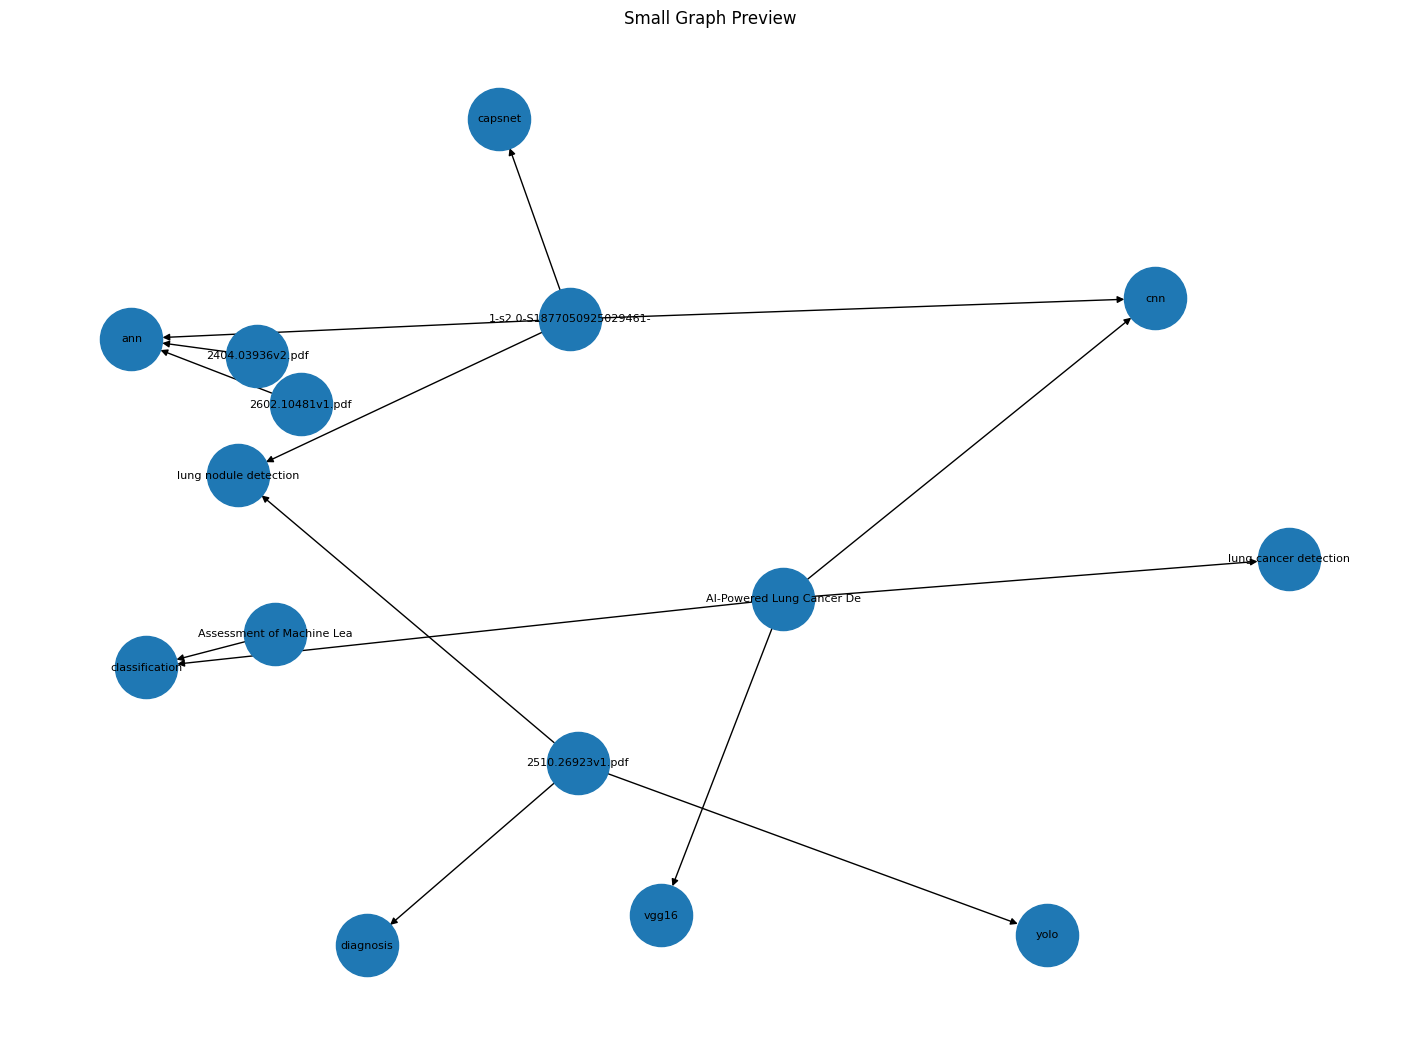

In [14]:
def plot_small_graph(G: nx.MultiDiGraph, max_nodes: int = 20):
    nodes = list(G.nodes())[:max_nodes]
    subG = G.subgraph(nodes)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(subG, seed=42)

    labels = {n: G.nodes[n].get("label", n)[:25] for n in subG.nodes()}
    nx.draw(subG, pos, with_labels=True, labels=labels, node_size=2000, font_size=8)
    plt.title("Small Graph Preview")
    plt.show()


plot_small_graph(knowledge_graph, max_nodes=15)

In [15]:
def build_embedding_model(model_name: str):
    print("=" * 100)
    print("STEP 6: LOADING EMBEDDING MODEL")
    print("=" * 100)

    embedding_model = HuggingFaceEmbeddings(model_name=model_name)
    print(f"Loaded embedding model: {model_name}")
    return embedding_model


embedding_model = build_embedding_model(config.embedding_model_name)

STEP 6: LOADING EMBEDDING MODEL


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded embedding model: sentence-transformers/all-MiniLM-L6-v2


In [16]:
def build_vectorstore(chunks: List[Document], embedding_model) -> FAISS:
    print("=" * 100)
    print("STEP 7: BUILDING FAISS VECTOR STORE")
    print("=" * 100)

    vectorstore = FAISS.from_documents(chunks, embedding_model)
    print(f"Indexed chunks: {len(chunks)}")
    return vectorstore


vectorstore = build_vectorstore(chunks, embedding_model)

STEP 7: BUILDING FAISS VECTOR STORE
Indexed chunks: 1512


## Graph search from query

In [17]:
def extract_entities_from_query(query: str) -> Dict[str, List[str]]:
    return {
        "datasets": find_pattern_matches(query, DATASET_PATTERNS),
        "methods": find_pattern_matches(query, METHOD_PATTERNS),
        "metrics": find_pattern_matches(query, METRIC_PATTERNS),
        "tasks": find_pattern_matches(query, TASK_PATTERNS)
    }


def graph_search_relevant_papers(query: str, G: nx.MultiDiGraph) -> List[str]:
    extracted = extract_entities_from_query(query)
    matched_nodes = []

    for ds in extracted["datasets"]:
        matched_nodes.append(f"dataset::{ds}")
    for m in extracted["methods"]:
        matched_nodes.append(f"method::{m}")
    for metric in extracted["metrics"]:
        matched_nodes.append(f"metric::{metric}")
    for task in extracted["tasks"]:
        matched_nodes.append(f"task::{task}")

    matched_papers = set()

    for node in matched_nodes:
        if node in G:
            for pred in G.predecessors(node):
                if G.nodes[pred].get("node_type") == "paper":
                    matched_papers.add(G.nodes[pred]["label"])

    return sorted(list(matched_papers))

In [18]:
def filter_chunks_by_papers(chunks: List[Document], selected_papers: List[str]) -> List[Document]:
    selected_set = set(selected_papers)
    return [c for c in chunks if c.metadata.get("file_name") in selected_set]

In [19]:
# Build local hybrid retriever
def build_local_hybrid_retriever(filtered_chunks: List[Document],
                                 embedding_model,
                                 dense_top_k: int,
                                 sparse_top_k: int):
    local_vectorstore = FAISS.from_documents(filtered_chunks, embedding_model)

    dense_retriever = local_vectorstore.as_retriever(
        search_kwargs={"k": min(dense_top_k, len(filtered_chunks))}
    )

    sparse_retriever = BM25Retriever.from_documents(filtered_chunks)
    sparse_retriever.k = min(sparse_top_k, len(filtered_chunks))

    hybrid_retriever = EnsembleRetriever(
        retrievers=[sparse_retriever, dense_retriever],
        weights=[0.5, 0.5]
    )

    return dense_retriever, sparse_retriever, hybrid_retriever

In [20]:
#Full Graph RAG retrieval function
def retrieve_graph_rag(query: str,
                       chunks: List[Document],
                       G: nx.MultiDiGraph,
                       embedding_model,
                       config: GraphRAGConfig,
                       debug: bool = True) -> Dict[str, Any]:

    matched_papers = graph_search_relevant_papers(query, G)

    if debug:
        print("=" * 100)
        print("STEP 8: GRAPH SEARCH")
        print("=" * 100)
        print("Query:", query)
        print("Matched papers from graph:")
        for p in matched_papers:
            print("-", p)

    # fallback: if graph does not find anything, use all chunks
    if matched_papers:
        filtered_chunks = filter_chunks_by_papers(chunks, matched_papers)
    else:
        filtered_chunks = chunks

    if debug:
        print(f"\nFiltered chunk count: {len(filtered_chunks)}")

    dense_retriever, sparse_retriever, hybrid_retriever = build_local_hybrid_retriever(
        filtered_chunks=filtered_chunks,
        embedding_model=embedding_model,
        dense_top_k=config.dense_top_k,
        sparse_top_k=config.sparse_top_k
    )

    retrieved_docs = hybrid_retriever.invoke(query)[:config.final_top_k]

    if debug:
        print("\nTop retrieved docs:")
        for i, doc in enumerate(retrieved_docs, start=1):
            print("-" * 100)
            print(f"Rank {i}")
            print("File:", doc.metadata.get("file_name"))
            print("Page:", doc.metadata.get("page"))
            print(doc.page_content[:600])

    return {
        "query": query,
        "matched_papers": matched_papers,
        "retrieved_docs": retrieved_docs
    }

In [26]:
from langchain_google_genai import ChatGoogleGenerativeAI
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["GOOGLE_API_KEY"] = user_secrets.get_secret("GOOGLE_API_KEY")

def build_llm(model_name: str, temperature: float):
    print("=" * 100)
    print("STEP 7: LOADING LLM")
    print("=" * 100)

    llm = ChatGoogleGenerativeAI(
        model=model_name,
        temperature=temperature
    )

    print(f"LLM initialized successfully: {model_name}")
    return llm


llm = build_llm(config.llm_model_name, config.temperature)

STEP 7: LOADING LLM
LLM initialized successfully: gemini-2.5-flash


In [30]:
result = retrieve_graph_rag(
    query="What dataset was used in the Lung Cancer Detection paper?",
    chunks=chunks,
    G=knowledge_graph,
    embedding_model=embedding_model,
    config=config,
    debug=True
)

STEP 8: GRAPH SEARCH
Query: What dataset was used in the Lung Cancer Detection paper?
Matched papers from graph:
- AI-Powered Lung Cancer Detection- Assessing VGG16 and CNN Architectures for CT Scan Image Classification.pdf
- Deep learning-based approach to diagnose lung cancer using CT-scan images.pdf
- fmed-12-1567119.pdf

Filtered chunk count: 355

Top retrieved docs:
----------------------------------------------------------------------------------------------------
Rank 1
File: fmed-12-1567119.pdf
Page: 1
compared through model training and testing, and their accuracy, 
reasoning speed, and applicability were analyzed.
Literature review
Object detection is a core technology used in computer vision. 
This method can be carried out in films or photos to identify and 
provide the object’s bounding box and category. Object detection is 
mainly divided into two modes: Two-Stage Detection and Single-
Stage Detection. Two-Stage Detection models include Faster R-CNN, 
R-FCN, and Cascade R

In [31]:
context = "\n\n".join([doc.page_content for doc in result["retrieved_docs"]])

In [33]:
query="What dataset was used in the Lung Cancer Detection paper?"

prompt = f"""
You are an AI assistant answering questions based ONLY on the provided context.

Context:
{context}

Question:
{query}

Instructions:
1. Answer the question using ONLY the retrieved context.
2. The system has already selected the most relevant candidate papers.
3. Do not mix in information from papers outside the selected candidate papers.
4. If the query refers to a specific paper but the identity is still ambiguous, clearly say so.
5. If the answer is not available in the retrieved context, say:
   "I could not find the answer in the provided context."
6. Always cite file name and page number when possible.
7. For comparison questions, compare only papers actually supported by the retrieved context.

Answer:
"""

In [34]:
response = llm.invoke(prompt)

In [35]:
response

AIMessage(content='The dataset used in the Lung Cancer Detection paper is the "Chest CT-Scan Images Dataset" obtained from Kaggle. This dataset was compiled by Mohammad Hany and consists of 1000 CT scan images representing various types of lung cancer, categorized into Adenocarcinoma, Large cell carcinomas, Squamous cell carcinomas, and Normal cells.\n\n(Context, page 3.2. Data loading section)', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8d91-a396-7500-b8ab-78f4486ea4db-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1127, 'output_tokens': 268, 'total_tokens': 1395, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 186}})

In [37]:
response.content

'The dataset used in the Lung Cancer Detection paper is the "Chest CT-Scan Images Dataset" obtained from Kaggle. This dataset was compiled by Mohammad Hany and consists of 1000 CT scan images representing various types of lung cancer, categorized into Adenocarcinoma, Large cell carcinomas, Squamous cell carcinomas, and Normal cells.\n\n(Context, page 3.2. Data loading section)'

In [38]:
response.usage_metadata

{'input_tokens': 1127,
 'output_tokens': 268,
 'total_tokens': 1395,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 186}}